# 2장 실습 — 5분 빠른 시작 (MNIST 분류 SNN)

**Spiking Neural Networks 쿡북 with Python** · 2장 실습 노트북

이 노트북에서는 **첫 스파이킹 신경망**을 처음부터 끝까지 돌려본다. MNIST 손글씨 숫자를 불러와 합성곱 스파이킹 신경망(CSNN)을 정의하고, 시간 스텝을 따라 순전파하며 학습시킨 뒤, 정확도를 확인한다. 세부 이론(대리 경사, BPTT 등)은 이후 장에서 깊게 다루므로, 여기서는 **전체 흐름**을 손에 익히는 데 집중한다.

### 학습 목표
- MNIST 데이터를 불러와 DataLoader를 만든다.
- `snn.Leaky` 층으로 합성곱 스파이킹 신경망을 정의한다.
- 시간 전개 순전파 → 손실 → 역전파(BPTT) → 갱신의 학습 한 사이클을 실행한다.
- 누적 스파이크 기반으로 정확도를 평가한다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 설치와 임포트

학습에 필요한 모듈을 불러온다.
- `surrogate`: 스파이크의 미분 불가능 문제를 우회하는 **대리 경사**
- `functional`(`SF`): 스파이크 기반 손실·정확도 함수
- `utils`: 순전파 전 뉴런 상태를 초기화하는 `reset` 등

이 실습은 CPU만으로 충분하다.

In [1]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate          # 대리 경사
from snntorch import functional as SF   # 스파이크 손실·정확도
from snntorch import utils              # 상태 초기화 도우미

torch.manual_seed(42)            # 재현성을 위한 시드 고정
device = torch.device('cpu')     # 이 실습은 CPU로 진행
print('사용 장치:', device)

사용 장치: cpu


## 2. 데이터 준비 (MNIST)

MNIST를 내려받아 텐서로 변환하고 정규화한다. 빠른 실습을 위해 `utils.data_subset`으로 학습 데이터의 **1/10만** 사용한다. `DataLoader`는 데이터를 배치 단위로 섞어 공급한다.

In [2]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

batch_size = 128
data_path = '/tmp/data/mnist'

# 이미지를 텐서로 바꾸고 평균 0, 표준편차 1로 정규화
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,)),
])

mnist_train = datasets.MNIST(
    data_path, 
    train=True, 
    download=True, 
    transform=transform
)
mnist_test = datasets.MNIST(
    data_path, 
    train=False, 
    download=True, 
    transform=transform
)

# 빠른 실습을 위해 학습셋의 1/10만 사용
mnist_train = utils.data_subset(mnist_train, subset=10)

train_loader = DataLoader(
    mnist_train, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True
)
test_loader = DataLoader(
    mnist_test, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True
)

print('학습 샘플 수:', len(mnist_train))

학습 샘플 수: 6000


## 3. 스파이킹 합성곱 신경망(CSNN) 정의

`nn.Sequential`로 합성곱 층과 스파이킹 뉴런 층을 번갈아 쌓는다. 각 `snn.Leaky` 인자의 의미는 다음과 같다.
- `beta`: 막전위 감쇠율
- `spike_grad`: 발화 함수의 **대리 경사**(여기서는 fast sigmoid). 이것이 있어 역전파가 가능하다.
- `init_hidden=True`: 막전위 상태를 층 내부에서 자동 관리
- `output=True`: 마지막 층이 `(스파이크, 막전위)`를 함께 반환하도록 지정

입력은 1채널 28×28 이미지이며, 두 번의 합성곱·풀링을 거쳐 10개 클래스로 분류된다.

In [3]:
beta = 0.9                              # 막전위 감쇠율
spike_grad = surrogate.fast_sigmoid()   # 대리 경사 함수

net = nn.Sequential(
    nn.Conv2d(1, 8, 5),                                                  # 합성곱 1
    nn.MaxPool2d(2),                                                     # 풀링 1
    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),       # 스파이킹 층 1
    nn.Conv2d(8, 16, 5),                                                 # 합성곱 2
    nn.MaxPool2d(2),                                                     # 풀링 2
    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),       # 스파이킹 층 2
    nn.Flatten(),                                                        # 1차원으로 펴기
    nn.Linear(16 * 4 * 4, 10),                                           # 완전연결 → 10클래스
    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True, output=True),  # 출력 스파이킹 층
).to(device)

print(net)

Sequential(
  (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
  (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (2): Leaky()
  (3): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Leaky()
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=256, out_features=10, bias=True)
  (8): Leaky()
)


## 4. 시간 전개 순전파 함수

SNN은 같은 입력을 `num_steps`번 반복해 흘려보내며 막전위를 누적한다. 매 스텝의 출력 스파이크를 모아 `(num_steps, 배치, 10)` 형태의 텐서로 돌려준다. 순전파를 시작하기 전에는 `utils.reset(net)`으로 모든 뉴런의 막전위를 0으로 되돌린다.

In [4]:
def forward_pass(net, data, num_steps):
    spk_rec = []                       # 시간별 출력 스파이크 기록
    utils.reset(net)                   # 모든 LIF 뉴런 막전위 초기화

    # 같은 입력을 num_steps번 반복해 시간으로 전개
    for step in range(num_steps):
        spk_out, mem_out = net(data)   # 한 시간 스텝 순전파
        spk_rec.append(spk_out)        # 출력 스파이크 저장

    return torch.stack(spk_rec)        # (num_steps, 배치, 10)

## 5. 손실·옵티마이저와 학습 루프

손실은 `SF.mse_count_loss`를 쓴다. 정답 클래스 뉴런은 자주(80%), 오답 뉴런은 드물게(20%) 발화하도록 **스파이크 개수**를 유도하는 손실이다. 시간으로 펼친 그래프에 대해 `backward()`를 호출하면 곧 BPTT가 수행된다. 학습 진행을 보기 위해 반복마다 손실을 출력한다.

In [5]:
optimizer = torch.optim.Adam(net.parameters(), lr=2e-3, betas=(0.9, 0.999))
loss_fn = SF.mse_count_loss(correct_rate=0.8, incorrect_rate=0.2)

num_steps = 25   # 시간 스텝 수
num_epochs = 1   # 데모용 1 에폭
loss_hist = []   # 손실 기록

net.train()
for epoch in range(num_epochs):
    for data, targets in train_loader:
        data = data.to(device)
        targets = targets.to(device)

        spk_rec = forward_pass(net, data, num_steps)   # 시간 전개 순전파
        loss_val = loss_fn(spk_rec, targets)           # 스파이크 수 기반 손실

        optimizer.zero_grad()   # 이전 기울기 초기화
        loss_val.backward()     # 역전파(BPTT)로 기울기 계산
        optimizer.step()        # 가중치 갱신

        loss_hist.append(loss_val.item())
        print(f'반복 손실: {loss_val.item():.3f}')

반복 손실: 2.460
반복 손실: 2.349
반복 손실: 2.029
반복 손실: 1.521
반복 손실: 1.209
반복 손실: 1.306
반복 손실: 1.152
반복 손실: 0.933
반복 손실: 0.926
반복 손실: 0.964
반복 손실: 1.035
반복 손실: 1.019
반복 손실: 1.010
반복 손실: 0.949
반복 손실: 0.913
반복 손실: 0.922
반복 손실: 0.894
반복 손실: 0.840
반복 손실: 0.772
반복 손실: 0.769
반복 손실: 0.813
반복 손실: 0.809
반복 손실: 0.746
반복 손실: 0.772
반복 손실: 0.741
반복 손실: 0.712
반복 손실: 0.678
반복 손실: 0.675
반복 손실: 0.667
반복 손실: 0.631
반복 손실: 0.650
반복 손실: 0.630
반복 손실: 0.617
반복 손실: 0.630
반복 손실: 0.586
반복 손실: 0.565
반복 손실: 0.564
반복 손실: 0.573
반복 손실: 0.563
반복 손실: 0.553
반복 손실: 0.525
반복 손실: 0.528
반복 손실: 0.540
반복 손실: 0.545
반복 손실: 0.516
반복 손실: 0.474


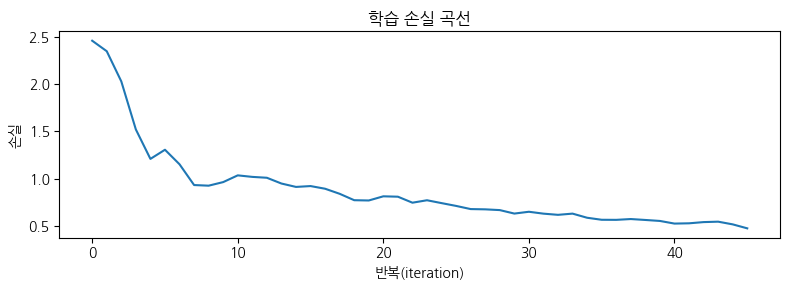

In [6]:
# 학습 곡선 시각화
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.figure(figsize=(8, 3))
plt.plot(loss_hist, color='tab:blue')
plt.xlabel('반복(iteration)')
plt.ylabel('손실')
plt.title('학습 손실 곡선')
plt.tight_layout()
plt.show()

## 6. 정확도 평가

출력 해석은 간단하다. `num_steps` 동안 각 출력 뉴런이 낸 **누적 스파이크 수**를 세고, 가장 많이 발화한 뉴런을 예측 클래스로 본다. `SF.accuracy_rate`가 이 계산을 대신해 준다. 평가 시에는 `torch.no_grad()`로 기울기 계산을 꺼 메모리를 아낀다.

In [7]:
def measure_accuracy(net, data_loader, num_steps):
    total = 0
    acc = 0.0
    net.eval()

    with torch.no_grad():   # 평가 단계에서는 기울기 계산 비활성화
        for data, targets in data_loader:
            data = data.to(device)
            targets = targets.to(device)

            spk_rec = forward_pass(net, data, num_steps)
            acc += SF.accuracy_rate(spk_rec, targets) * spk_rec.size(1)
            total += spk_rec.size(1)

    return acc / total

test_acc = measure_accuracy(net, test_loader, num_steps)
print(f'테스트 정확도: {test_acc * 100:.2f}%')

테스트 정확도: 75.94%


## 7. 한 배치 예측 들여다보기

테스트 배치 하나를 골라, 한 샘플의 출력 뉴런별 누적 스파이크 수를 막대그래프로 본다. 가장 높은 막대가 모델의 예측 숫자다.

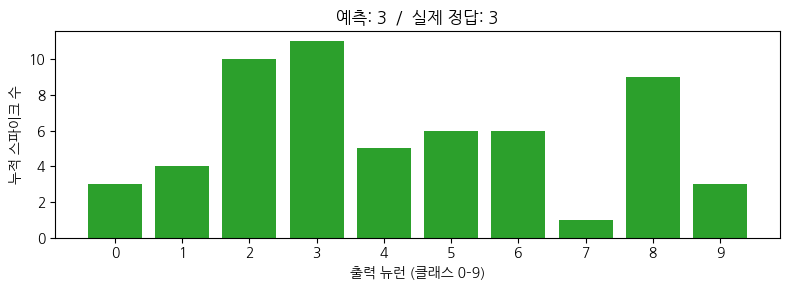

In [8]:
data, targets = next(iter(test_loader))
data = data.to(device)

spk_rec = forward_pass(net, data, num_steps)   # (num_steps, 배치, 10)
counts = spk_rec.sum(dim=0)                    # 시간 축 합 → (배치, 10)

idx = 0                                        # 배치의 첫 번째 샘플
sample_counts = counts[idx].detach().numpy()
predicted = int(sample_counts.argmax())

plt.figure(figsize=(8, 3))
plt.bar(range(10), sample_counts, color='tab:green')
plt.xticks(range(10))
plt.xlabel('출력 뉴런 (클래스 0–9)')
plt.ylabel('누적 스파이크 수')
plt.title(f'예측: {predicted}  /  실제 정답: {int(targets[idx])}')
plt.tight_layout()
plt.show()

## 정리

- SNN 추론은 **인코딩(여기선 입력 반복) → 스파이킹 층 → 시간 전개 → 출력 집계**의 파이프라인이다.
- `snn.Leaky(... spike_grad=...)` 덕분에 발화의 비미분 문제를 우회해 BPTT로 학습할 수 있다.
- 출력은 누적 스파이크 수의 `argmax`로 읽고, 손실은 미분 가능해 평범한 경사하강법으로 학습한다.
- 더 높은 정확도를 원하면 `num_epochs`를 늘리거나 학습셋 `subset` 값을 줄여 더 많은 데이터를 쓰면 된다.

다음 2부에서는 스파이크 인코딩과 LIF 뉴런을 한 단계씩 더 깊게 파고든다.